In [1]:
!pip uninstall -y pyarrow
!pip install pyarrow --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 510.3 MB/s  0:00:00


In [2]:
!pip uninstall -y scipy
!pip install scipy==1.11.4 --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 73.3 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 534.6 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]


In [3]:
!pip uninstall -y numpy scipy scikit-learn
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 --no-cache-dir

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 532.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 176.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 228.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [6]:
pip install matplotlib seaborn s3fs joblib boto3 scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


## 1. Librerias

In [8]:
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import s3fs
import joblib
import boto3

from sklearn.impute             import SimpleImputer
from sklearn.ensemble           import RandomForestClassifier
from sklearn.model_selection    import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics            import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.colors import LinearSegmentedColormap

## 2. Configuración general

In [9]:
BUCKET = "tfm-mu-ecg"
S3_BASE = "s3://tfm-mu-ecg/processed"
S3_OUT  = "s3://tfm-mu-ecg/outputs/random_forest_complete"
s3 = s3fs.S3FileSystem()
s3_client = boto3.client("s3")

EXCLUDE_COLS = [
    "record_id", "dx", "labels", "categories",
    "is_adverse", "snomed_unknown", "dx_multi_hot", "cat_arrhythmia",
    "cat_axis_deviation", "cat_conduction_block", "cat_interval_change", "cat_ischemia",        
    "cat_morphology_change", "cat_repolarization",  
    "cat_sinus_rhythm", "cat_structural"   
]

RANDOM_STATE = 42
colors = [
    "#cdeae5",
    "#a8dadc",
    "#77abbd",
    "#457b9d",
    "#31587a",
    "#1d3557",
    "#324766"
]
cmap     = LinearSegmentedColormap.from_list("custom_blue", colors)
C_MID    = "#457b9d"
C_DARK   = "#1d3557"
C_ACCENT = "#77abbd"
C_BG     = "#f4f9fb"
C_GRID   = "#dce9ef"


## 3. Carga y preparación

In [10]:
def prepare_features(df, feature_cols):
    X = df[feature_cols].copy()
    for col in feature_cols:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.values.astype(np.float32)


def load_and_prepare():
    print("Cargando datos desde S3...")
    df_train = pd.read_parquet(f"{S3_BASE}/machine_learning/ml_train.parquet")
    df_val = pd.read_parquet(f"{S3_BASE}/machine_learning/ml_val.parquet")
    df_test = pd.read_parquet(f"{S3_BASE}/machine_learning/ml_test.parquet")

    feature_cols = [c for c in df_train.columns if c not in EXCLUDE_COLS]

    imputer = SimpleImputer(strategy="median")

    X_train_raw = prepare_features(df_train, feature_cols)
    X_val_raw = prepare_features(df_val, feature_cols)
    X_test_raw = prepare_features(df_test, feature_cols)

    X_train = imputer.fit_transform(X_train_raw)
    X_val = imputer.transform(X_val_raw)
    X_test = imputer.transform(X_test_raw)

    y_train = df_train["is_adverse"].astype(int).values
    y_val = df_val["is_adverse"].astype(int).values
    y_test = df_test["is_adverse"].astype(int).values

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    print(f" Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f" Train+Val: {X_trainval.shape}")

    return (X_train, y_train, X_val, y_val,
            X_test, y_test, X_trainval, y_trainval,
            feature_cols, imputer)

## 4. Tunning

In [11]:
def tune_rf(X_train, y_train):
    print("\nTuning de hiperparámetros")

    param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
        "bootstrap": [True, False],
    }

    base_model = RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=30,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f"\nMejores parámetros: {search.best_params_}")
    print(f"Mejor AUC-ROC (CV): {search.best_score_:.4f}")

    return search.best_params_, search.best_score_

## 5. Entrenamiento y evaluación

In [12]:
def train_final(best_params, X_trainval, y_trainval):
    print("\n Entrenamiento final")

    model = RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_trainval, y_trainval)
    print(f" Árboles entrenados: {model.n_estimators}")
    return model

def evaluate_full(model, X, y, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    auc = roc_auc_score(y, y_prob)
    f1 = f1_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    ap = average_precision_score(y, y_prob)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    print(f"\n  [{split_name}]")
    print(f" AUC-ROC: {auc:.4f}")
    print(f" AUC-PR: {ap:.4f}")
    print(f" F1: {f1:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall: {rec:.4f}")
    print(f" Specificity: {specificity:.4f}")
    print(f" Confusion matrix:\n{cm}")

    return {
        "split": split_name,
        "auc_roc": round(auc,  4),
        "auc_pr": round(ap,   4),
        "f1": round(f1,   4),
        "precision": round(prec, 4),
        "recall": round(rec,  4),
        "specificity": round(specificity, 4),
        "cm": cm.tolist(),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)
    }

## 6. Visualización y subida a s3

In [15]:
def _apply_style(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(C_BG)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_edgecolor(C_GRID)
    if title:   ax.set_title(title, fontsize=12, fontweight="bold", color=C_DARK, pad=10)
    if xlabel:  ax.set_xlabel(xlabel, fontsize=10, color=C_DARK)
    if ylabel:  ax.set_ylabel(ylabel, fontsize=10, color=C_DARK)
    ax.tick_params(colors=C_DARK, labelsize=9)


def run_evaluation_plots(model, X_val, y_val, X_test, y_test, feature_cols, threshold=0.5, top_n=20):

    # Probabilidades
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # Predicciones
    y_pred_test = (y_prob_test >= threshold).astype(int)

    # ===================== ROC =====================
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), facecolor=C_BG)

    fpr_v, tpr_v, _ = roc_curve(y_val, y_prob_val)
    fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)

    ax[0].plot(fpr_v, tpr_v, color=C_MID, label="Val")
    ax[0].plot(fpr_t, tpr_t, color=C_ACCENT, linestyle="--", label="Test")
    ax[0].plot([0, 1], [0, 1], color=C_DARK, linestyle=":")

    _apply_style(ax[0], "ROC Curve", "FPR", "TPR")
    ax[0].legend()

    # ===================== PR =====================
    p_v, r_v, _ = precision_recall_curve(y_val, y_prob_val)
    p_t, r_t, _ = precision_recall_curve(y_test, y_prob_test)

    ax[1].plot(r_v, p_v, color=C_MID, label="Val")
    ax[1].plot(r_t, p_t, color=C_ACCENT, linestyle="--", label="Test")

    _apply_style(ax[1], "Precision-Recall Curve", "Recall", "Precision")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # ===================== CONFUSION MATRIX =====================
    fig, ax = plt.subplots(figsize=(6, 5), facecolor=C_BG)

    sns.heatmap(confusion_matrix(y_test, y_pred_test),
                annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)

    _apply_style(ax, f"Confusion Matrix (thr={threshold})")
    plt.tight_layout()
    plt.show()

    # ===================== FEATURE IMPORTANCE =====================
    fi = (pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_
         })
         .sort_values("importance")
         .tail(top_n))

    fig, ax = plt.subplots(figsize=(8, top_n * 0.4 + 1), facecolor=C_BG)

    ax.barh(fi["feature"], fi["importance"], color=C_DARK)

    _apply_style(ax, f"Feature Importance (Top {top_n})", "Importance")

    plt.tight_layout()
    plt.show()
    
def upload_to_s3():
    files = [
        "./rf_roc_pr.png",
        "./rf_confusion_matrix.png",
        "./rf_feature_importance.png",
        "./rf_feature_importance_std.png",
        "./rf_results.json",
    ]
    for local in files:
        remote = f"{S3_OUT}/{local.lstrip('./')}"
        try:
            s3.put(local, remote)
            print(f"  {local} → {remote}")
        except Exception as e:
            print(f" ERROR {local}: {e}")


## 7. Ejecución Principal

Cargando datos desde S3...
 Train: (31606, 62) | Val: (6773, 62) | Test: (6773, 62)
 Train+Val: (38379, 62)

Tuning de hiperparámetros
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
Mejor AUC-ROC (CV): 0.8980

 Entrenamiento final
 Árboles entrenados: 200

 Evaluación final

  [test]
 AUC-ROC: 0.8967
 AUC-PR: 0.8713
 F1: 0.7864
 Precision: 0.8256
 Recall: 0.7507
 Specificity: 0.8852
 Confusion matrix:
[[3478  451]
 [ 709 2135]]

 Generando visualizaciones


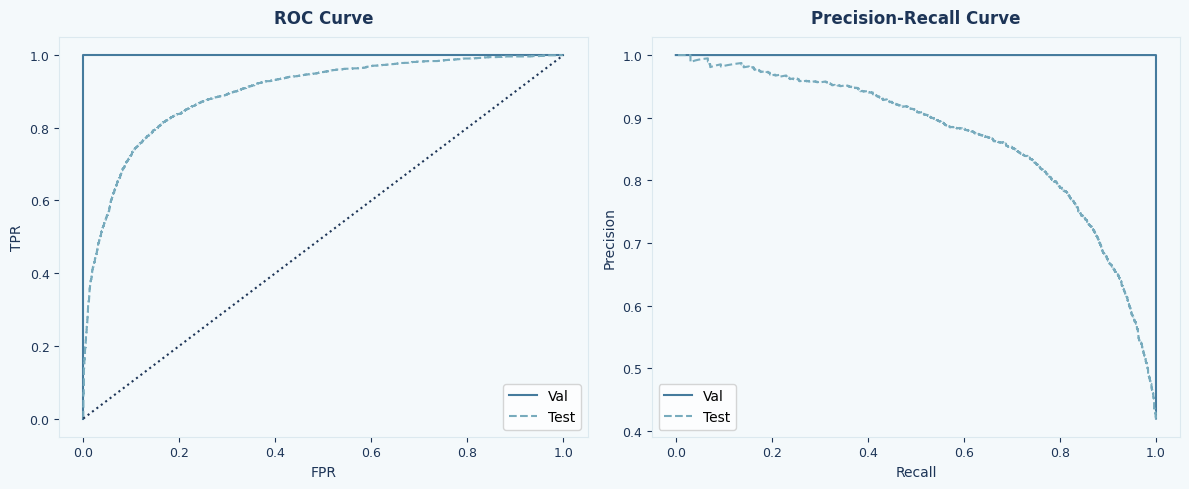

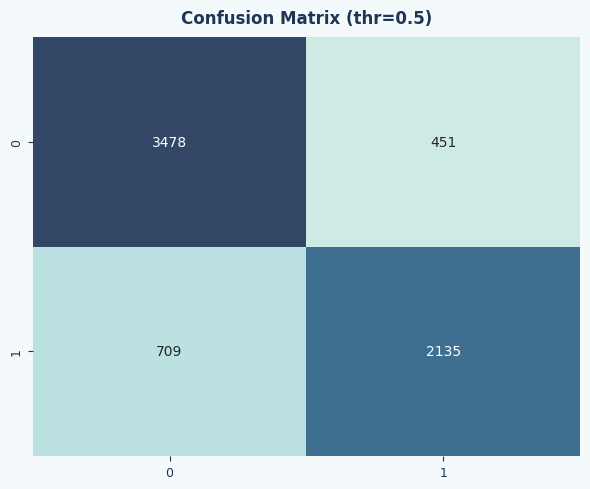

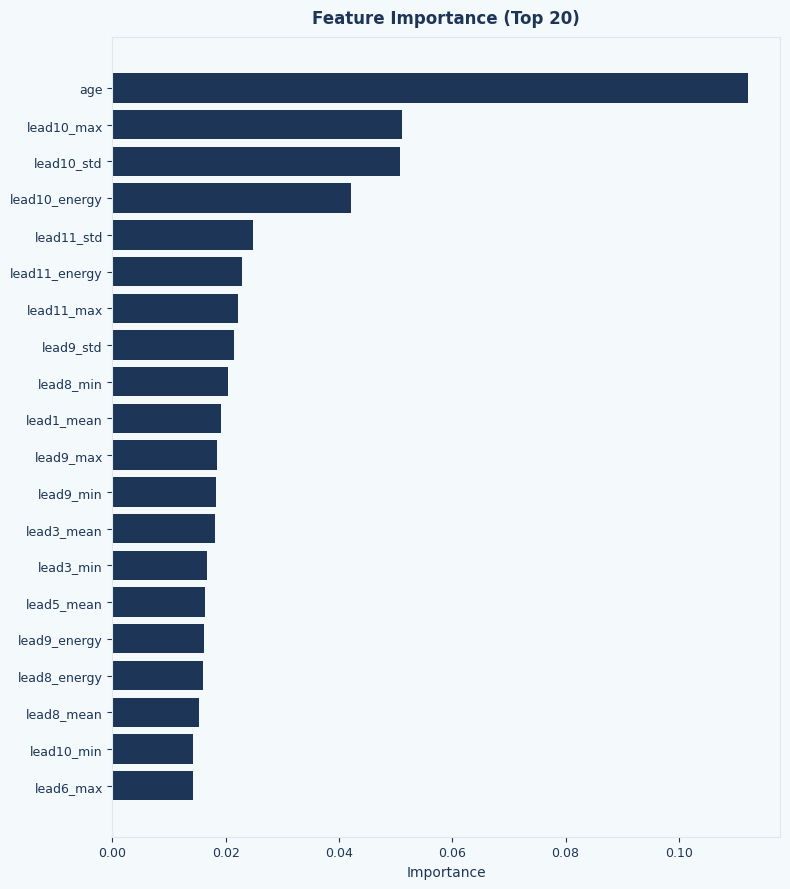

NameError: name 'plot_feature_importance' is not defined

In [17]:
if __name__ == "__main__":

    (X_train, y_train, X_val, y_val,
     X_test, y_test, X_trainval, y_trainval,
     feature_cols, imputer) = load_and_prepare()

    best_params, best_cv_score = tune_rf(X_train, y_train)

    final_model = train_final(best_params, X_trainval, y_trainval)

    print("\n Evaluación final")
    r_test = evaluate_full(final_model, X_test, y_test, "test")

    print("\n Generando visualizaciones")

    run_evaluation_plots(
        final_model,
        X_val, y_val,
        X_test, y_test,
        feature_cols,
        threshold=0.5
    )

    plot_feature_importance(final_model, feature_cols)
    plot_feature_importance_std(final_model, feature_cols)

    results = {
        "best_params": best_params,
        "best_cv_auc": round(best_cv_score, 4),
        "test": r_test
    }

    with open("./rf_results.json", "w") as f:
        json.dump(results, f, indent=2)

    print("\n rf_results.json guardado")

    print("\n Subiendo artefactos a S3")
    upload_to_s3()

    print("\n Random Forest Completo")
    print("\n RESUMEN TEST:")
    print(f" AUC-ROC: {r_test['auc_roc']}")
    print(f" AUC-PR: {r_test['auc_pr']}")
    print(f" F1: {r_test['f1']}")
    print(f" Recall: {r_test['recall']}")
    print(f" Specificity: {r_test['specificity']}")

## 8. Guardar modelo

In [18]:
    rf_model_path = "/tmp/rf_model.joblib"
    joblib.dump(final_model, rf_model_path)
    s3_client.upload_file(
        rf_model_path,
        BUCKET,
        "models/rf_model.joblib"
    )
    print(f"RF guardado en s3://{BUCKET}/models/rf_model.joblib")

RF guardado en s3://tfm-mu-ecg/models/rf_model.joblib
